# 04 - Sky View Factors: Advanced Surface Sensors

**What it computes.** The Sky View Factor (SVF) - the share of the sky hemi-
sphere visible from a point, **reported on a 0-100 scale** (0 = fully enclosed,
100 = fully open sky). It is **time-independent** (pure geometry), so there is
no `time-period` and no weather. SVF drives longwave cooling at night and is a
core input to thermal comfort. Standard = 512x512 ground grid; **advanced** =
SVF on building **facades** / roofs.

**Advanced inputs gained.** `analysis-surfaces`, `surface-grid-size`,
`partial-cells`, `sensor-points`, `ground-geometry`, `context-geometry`. (No
time window - SVF is geometric.)

**When to use.** Facade longwave exposure, urban canyon enclosure, night-time
cooling potential per facade.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city
buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


## Standard run (baseline grid)

SVF needs nothing but geometry - no weather, no time period.

In [2]:
from infrared_sdk.analyses.types import SvfModelRequest, AnalysesName


def svf_body():
    b = SvfModelRequest(analysis_type=AnalysesName.sky_view_factors).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    return b


grid_res, info = ia.run_job("sky-view-factors", svf_body(), label="grid")
grid = np.array(grid_res["output"], dtype=float)
print(
    "grid shape:",
    grid.shape,
    "| SVF range:",
    round(float(np.nanmin(grid)), 1),
    "->",
    round(float(np.nanmax(grid)), 1),
    "| legend:",
    grid_res.get("min-legend"),
    "->",
    grid_res.get("max-legend"),
)

[sky-view-factors/grid] Succeeded in 1.4s  keys=['max-legend', 'min-legend', 'output']
grid shape: (512, 512) | SVF range: -0.0 -> 99.4 | legend: 0 -> 100


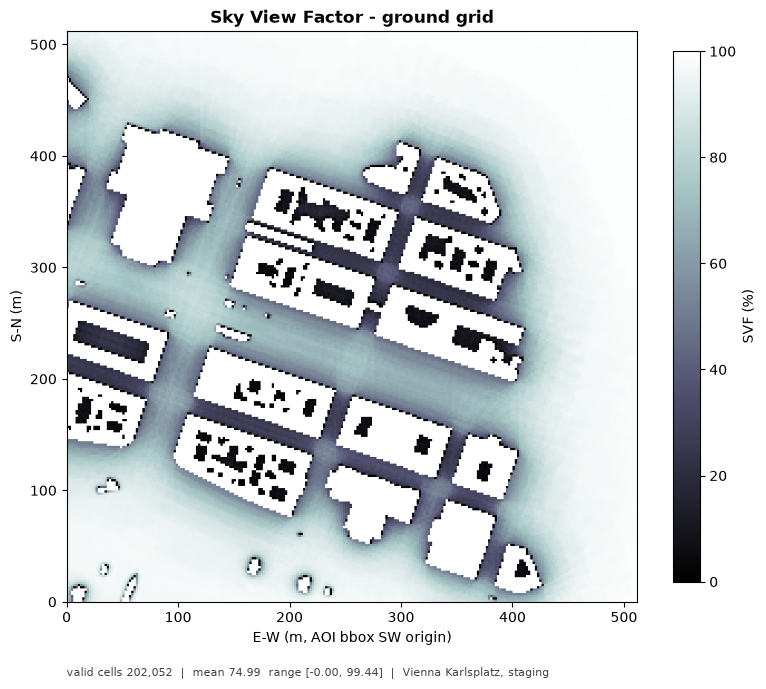

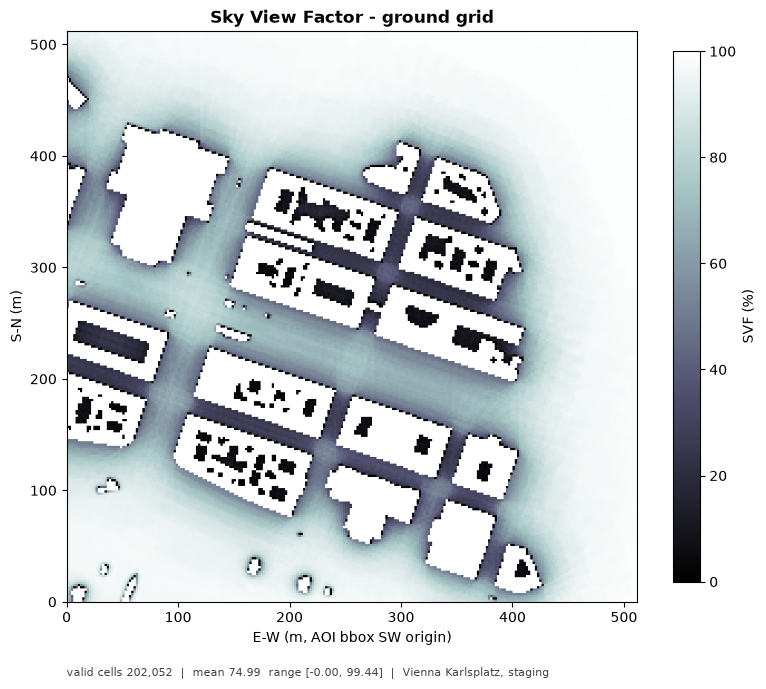

In [3]:
# SVF is reported on a 0-100 scale (not 0-1). Fix vmin/vmax so the variation
# shows instead of saturating; the legend confirms 0 -> 100.
fig, ax = ir.grid_heatmap(
    grid,
    title="Sky View Factor - ground grid",
    cbar_label="SVF (%)",
    cmap="bone",
    crop=True,
    vmin=0,
    vmax=100,
    note="Vienna Karlsplatz, staging",
)
fig

## Advanced run - facade SVF sensors

`analysis-surfaces:"facades"`. Facade SVF is lower in narrow canyons and
higher on tall exposed elevations - exactly what the colored mesh shows.

In [4]:
body = svf_body()
body["analysis-surfaces"] = "facades"
body["surface-grid-size"] = 4.0
body["surface-offset"] = 0.1
body["partial-cells"] = True
body["min-coverage"] = 0.25
fac_res, info = ia.run_job("sky-view-factors", body, label="facades")
print("frames:", len(fac_res["surfaces"]), "| sensors:", fac_res["sensor-count"])

[sky-view-factors/facades] Succeeded in 1.9s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=44276
frames: 2724 | sensors: 44276


### Result payload, described

Same surface schema as the solar models (notebook `01`): per-frame
`{origin, u-axis, v-axis, grid-size, nu, nv, values, cell-area, cell-tris,
area, mean, peak}` + `aggregates` + `sensor-count`. `values` are **SVF on the
0-100 scale** (legend `min-legend`/`max-legend` = `0`/`100`). Because SVF is
time-independent the *same* facade frames would come back for any season - only
the geometry matters.

In [5]:
import json

fk = next(iter(fac_res["surfaces"]))
print(
    "frame",
    fk,
    "->",
    json.dumps(
        {
            k: fac_res["surfaces"][fk][k]
            for k in ("grid-size", "nu", "nv", "mean", "peak")
        },
        default=float,
    ),
)
bid = fk.split("/")[0]
print(
    "building",
    bid,
    "aggregate:",
    json.dumps(fac_res["aggregates"]["buildings"].get(bid, {}), default=float),
)

frame 11155/0 -> {"grid-size": 4.0, "nu": 1, "nv": 8, "mean": 33.857421875, "peak": 49.65625}
building 11155 aggregate: {"area": 18048.0, "mean": 24.202543218085108, "peak": 49.6875}


## Render - colored SVF mesh on the building geometry

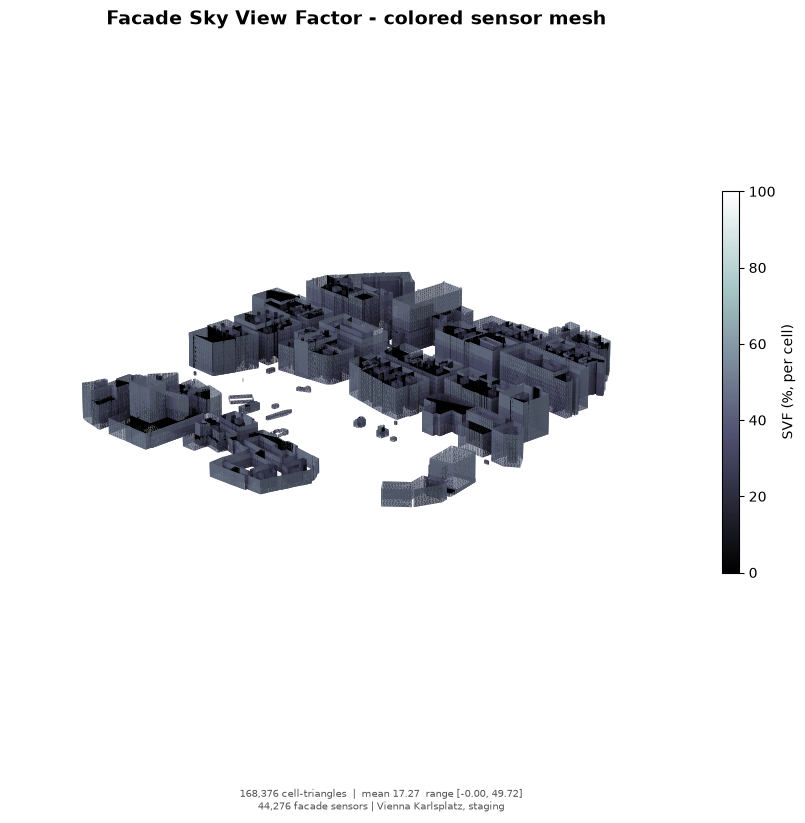

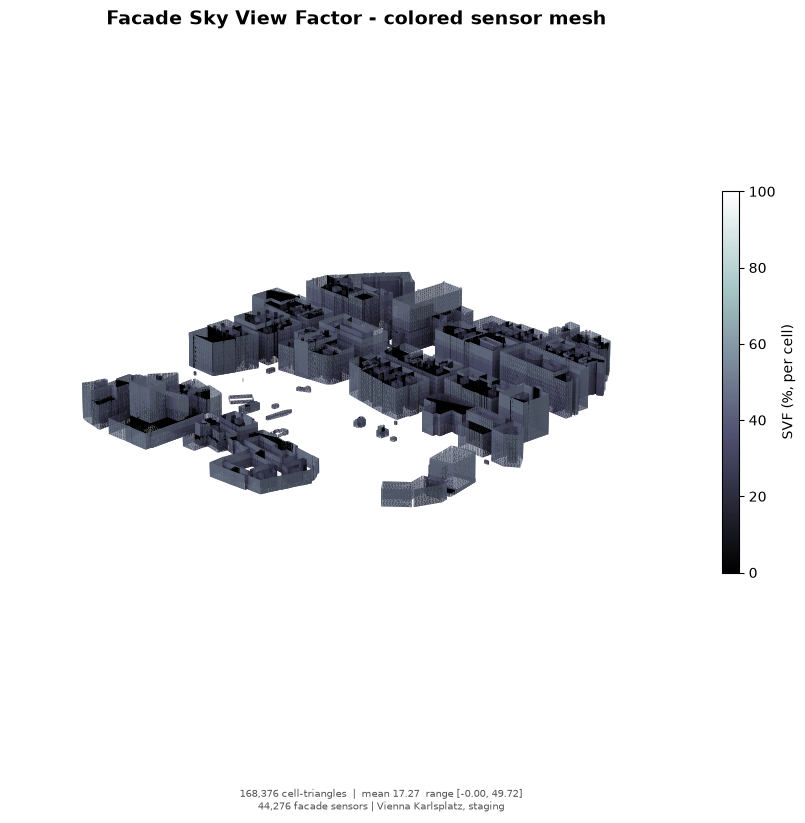

In [6]:
tris, values, normals = ia.reconstruct_cells(fac_res["surfaces"])
# SVF is 0-100; fix the scale so canyon vs exposed facades separate clearly.
fig, ax = ir.surface_mesh(
    tris,
    values,
    normals=normals,
    context_faces=ia.building_faces(buildings),
    title="Facade Sky View Factor - colored sensor mesh",
    cbar_label="SVF (%, per cell)",
    cmap="bone",
    zmax=45,
    vmin=0,
    vmax=100,
    note=f"{fac_res['sensor-count']:,} facade sensors | Vienna Karlsplatz, staging",
)
fig